In [26]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import os
import pickle
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from pymoo.indicators.hv import Hypervolume

from util import natural_key, load_yaml

In [28]:
def load_pareto_history(filepath="pareto_history.pkl"):
    """
    Carga el archivo pickle que contiene fronts_history.
    Devuelve un dict: {generacion: {nivel_frente: [registros...]}}
    """
    with open(filepath, "rb") as f:
        history = pickle.load(f)
    return history

In [29]:
def pareto_history_to_df(filepath="pareto_history.pkl", generation=None):
    """
    Convierte la historia de Pareto guardada en filepath en un DataFrame
    para la generación 'generation', con columnas:
        generation, front_level, accuracy, params, inference_time
    """
    history = load_pareto_history(filepath)
        
    if generation is None:
        generation = max(history.keys())
        
    gen_dict = history[generation]
    records = []
    for level, recs in gen_dict.items():
        # saltamos la métrica hypervolume
        if level == "hypervolume":
            continue
        for rec in recs:
            records.append({
                "id":             rec["id"],
                "generation":      generation,
                "front_level":     level,
                "accuracy":        rec["accuracy"],
                "params":          rec["params"],
                "inference_time":  rec["inference_time"]
            })
    return pd.DataFrame(records)

In [30]:
def archive_to_df(experiment_path: str, archive_subdir: str = "archive") -> pd.DataFrame:
    """Load training metrics from the archive directory into a DataFrame.

    Each folder inside ``archive_subdir`` should contain a ``training_params.txt``
    file with keys such as ``fitness_metric``, ``cuda_inference_time`` and
    ``total_params``. The value for ``fitness_metric`` is taken from the metric
    name specified in that file.

    Parameters
    ----------
    experiment_path : str
        Path to the root experiment directory.
    archive_subdir : str, optional
        Name of the subdirectory that stores archived results. Defaults to
        ``"archive"``.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns ``id``, ``fitness_metric``, ``cuda_inference_time``
        and ``total_params`` for all archived runs.
    """

    archive_dir = os.path.join(experiment_path, archive_subdir)
    if not os.path.isdir(archive_dir):
        raise FileNotFoundError(f"Archive folder not found at {archive_dir}")

    records = []
    for folder in sorted(os.listdir(archive_dir), key=natural_key):
        params_file = os.path.join(archive_dir, folder, "training_params.txt")
        if not os.path.isfile(params_file):
            continue

        params = load_yaml(params_file)
        metric_key = params.get("fitness_metric")
        if metric_key is None:
            continue

        fitness_value = params.get(metric_key)
        cuda_time = params.get("cuda_inference_time")
        tot_params = params.get("total_params")

        records.append(
            {
                "id": folder,
                "fitness_metric": fitness_value,
                "cuda_inference_time": cuda_time,
                "total_params": tot_params,
            }
        )

    return pd.DataFrame(records)

In [31]:
path_archive = "experiment_cifar10_moqnas/exp4_repeat_1"
df_archive = archive_to_df(path_archive)
df_archive.shape

(19, 4)

In [32]:
df_archive

,id,fitness_metric,cuda_inference_time,total_params
0,1_0,52.1,9517.288208,200490
1,2_0,42.1,11336.278915,63562
2,2_2,38.1,13777.589798,132458
3,2_3,28.2,11753.630638,5322
4,2_4,49.6,11751.794815,116618
5,2_5,38.1,11154.341698,75114
6,2_6,64.4,6888.747215,230410
7,2_7,54.3,13550.543785,112330
8,2_8,61.5,10266.423225,208778
9,3_0,54.6,7389.426231,659338


In [33]:
pkl_path = os.path.join(path_archive, "pareto_history.pkl")
df_history = pareto_history_to_df(pkl_path)
df_history = df_history[df_history["front_level"] == 1]

In [34]:
df_history

,id,generation,front_level,accuracy,params,inference_time
0,1_0,3,1,50.95,86570.0,19197.678566
1,2_0,3,1,50.95,86570.0,19197.678566
2,2_2,3,1,42.05,63562.0,11336.278915
3,2_3,3,1,28.14,5322.0,11753.630638
4,2_4,3,1,49.59,116618.0,11751.794815
5,2_5,3,1,38.05,75114.0,11154.341698
6,2_6,3,1,64.39,230410.0,6888.747215
7,2_7,3,1,54.27,112330.0,13550.543785
8,2_8,3,1,61.49,208778.0,10266.423225
9,3_0,3,1,46.74,58346.0,12419.509888


In [35]:
def find_pareto_front(df, objectives):
    """
    Encuentra el frente de Pareto en un DataFrame dado un conjunto de objetivos.

    Args:
        df (pd.DataFrame): El DataFrame de entrada.
        obj_columns (dict): Un diccionario donde las claves son los nombres de las columnas
                            y los valores son 'maximize' o 'minimize'.

    Returns:
        pd.DataFrame: Un DataFrame que contiene solo los puntos del frente de Pareto.
    """
    is_pareto = np.ones(len(df), dtype=bool)
    for i, row_i in df.iterrows():
        for j, row_j in df.iterrows():
            if i == j:
                continue

            dominated = True
            for obj_col, obj_type in objectives.items():
                if obj_type == 'maximize':
                    if row_j[obj_col] < row_i[obj_col]: # row_j no es mejor que row_i en esta dimensión
                        dominated = False
                        break
                elif obj_type == 'minimize':
                    if row_j[obj_col] > row_i[obj_col]: # row_j no es mejor que row_i en esta dimensión
                        dominated = False
                        break
            
            # Si todas las condiciones se mantienen (row_j es igual o mejor en todas las dimensiones)
            # Y row_j es estrictamente mejor en al menos una dimensión, entonces row_j domina a row_i.
            # Verificamos si row_j es estrictamente mejor en al menos una dimensión.
            if dominated:
                strictly_better = False
                for obj_col, obj_type in objectives.items():
                    if obj_type == 'maximize':
                        if row_j[obj_col] > row_i[obj_col]:
                            strictly_better = True
                            break
                    elif obj_type == 'minimize':
                        if row_j[obj_col] < row_i[obj_col]:
                            strictly_better = True
                            break
                
                if strictly_better:
                    is_pareto[i] = False
                    break
    return df[is_pareto]

# Definición de los objetivos
objectives = {
    'fitness_metric': 'maximize',
    'cuda_inference_time': 'minimize',
    'total_params': 'minimize'
}

pareto_front = find_pareto_front(df_archive.copy(), objectives) # Pasamos una copia para no modificar el original

print("\nFrente de Pareto:")
print(pareto_front)


Frente de Pareto:
     id  fitness_metric  cuda_inference_time  total_params
1   2_0            42.1         11336.278915         63562
3   2_3            28.2         11753.630638          5322
4   2_4            49.6         11751.794815        116618
5   2_5            38.1         11154.341698         75114
6   2_6            64.4          6888.747215        230410
7   2_7            54.3         13550.543785        112330
8   2_8            61.5         10266.423225        208778
10  3_1            57.1          6348.180771        189354
13  3_4            44.1          3805.685043        675690
15  3_6            59.7           973.844528       1241450
16  3_7            46.8         12419.509888         58346


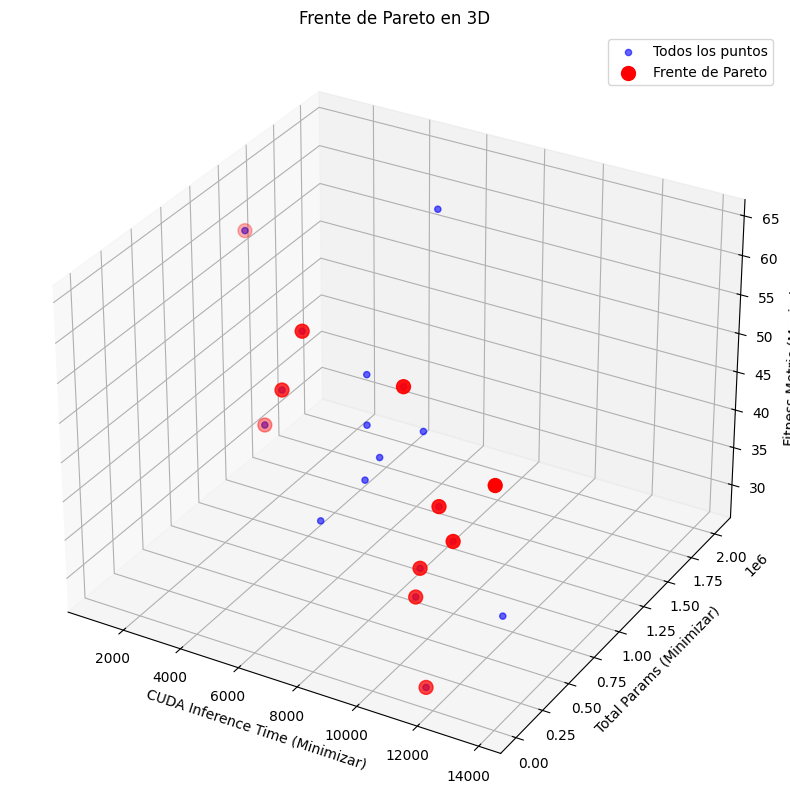

In [36]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Graficar todos los puntos
ax.scatter(df_archive['cuda_inference_time'], df_archive['total_params'], df_archive['fitness_metric'],
           c='blue', label='Todos los puntos', alpha=0.6)

# Graficar los puntos del frente de Pareto
ax.scatter(pareto_front['cuda_inference_time'], pareto_front['total_params'], pareto_front['fitness_metric'],
           c='red', marker='o', s=100, label='Frente de Pareto')

ax.set_xlabel('CUDA Inference Time (Minimizar)')
ax.set_ylabel('Total Params (Minimizar)')
ax.set_zlabel('Fitness Metric (Maximizar)')
ax.set_title('Frente de Pareto en 3D')
ax.legend()
plt.grid(True)
plt.show()